In [1]:
import sys; sys.path.append('..')
import torch
import matplotlib.pyplot as plt
from src.config.schemas import ExperimentConfig, GameConfig, DynamicConfig, ExecutionConfig
from src.engine.runner import ExperimentRunner
from src.engine.statistics import load_experiment_stats



In [2]:
payoffs = [[[-0.14084231853485107, 0.16276800632476807], [-0.13902530074119568, -0.1397189199924469]], [[0.07258868217468262, -0.5739840865135193], [-0.5174753665924072, -0.16868625581264496]]]

In [3]:
# 1. Configure OMWU on Matching Pennies starting OFF-equilibrium ([0.8, 0.2] & [0.3, 0.7])
config = ExperimentConfig(
    name="demo",
    game=GameConfig(generator="custom", utility_range=(-1.0, 1.0), payoffs=payoffs),
    dynamic=DynamicConfig(
        algorithm="omwu",
        strict_theory_eta=False,
        eta=0.01
    ),
    execution=ExecutionConfig(total_steps=1000000, device="auto",
        dtype="float32", # Can be float64 for higher precision steps_per_call=500, seed=42, compile=False)
)

# 2. Run simulation
runner = ExperimentRunner(config=config)
summary = runner.run()

In [4]:
output_dir = 'outputs'
session_id = '46b25ae2-b8ed-423e-a467-64cc8400322d' # eta = 0.01

In [8]:
strats

[tensor([[0.5000, 0.5000],
         [0.5004, 0.4996],
         [0.5008, 0.4992],
         ...,
         [0.1812, 0.8188],
         [0.1812, 0.8188],
         [0.1812, 0.8188]]),
 tensor([[5.0000e-01, 5.0000e-01],
         [5.0037e-01, 4.9963e-01],
         [5.0075e-01, 4.9925e-01],
         ...,
         [1.0000e+00, 9.6493e-42],
         [1.0000e+00, 9.6648e-42],
         [1.0000e+00, 9.6816e-42]])]

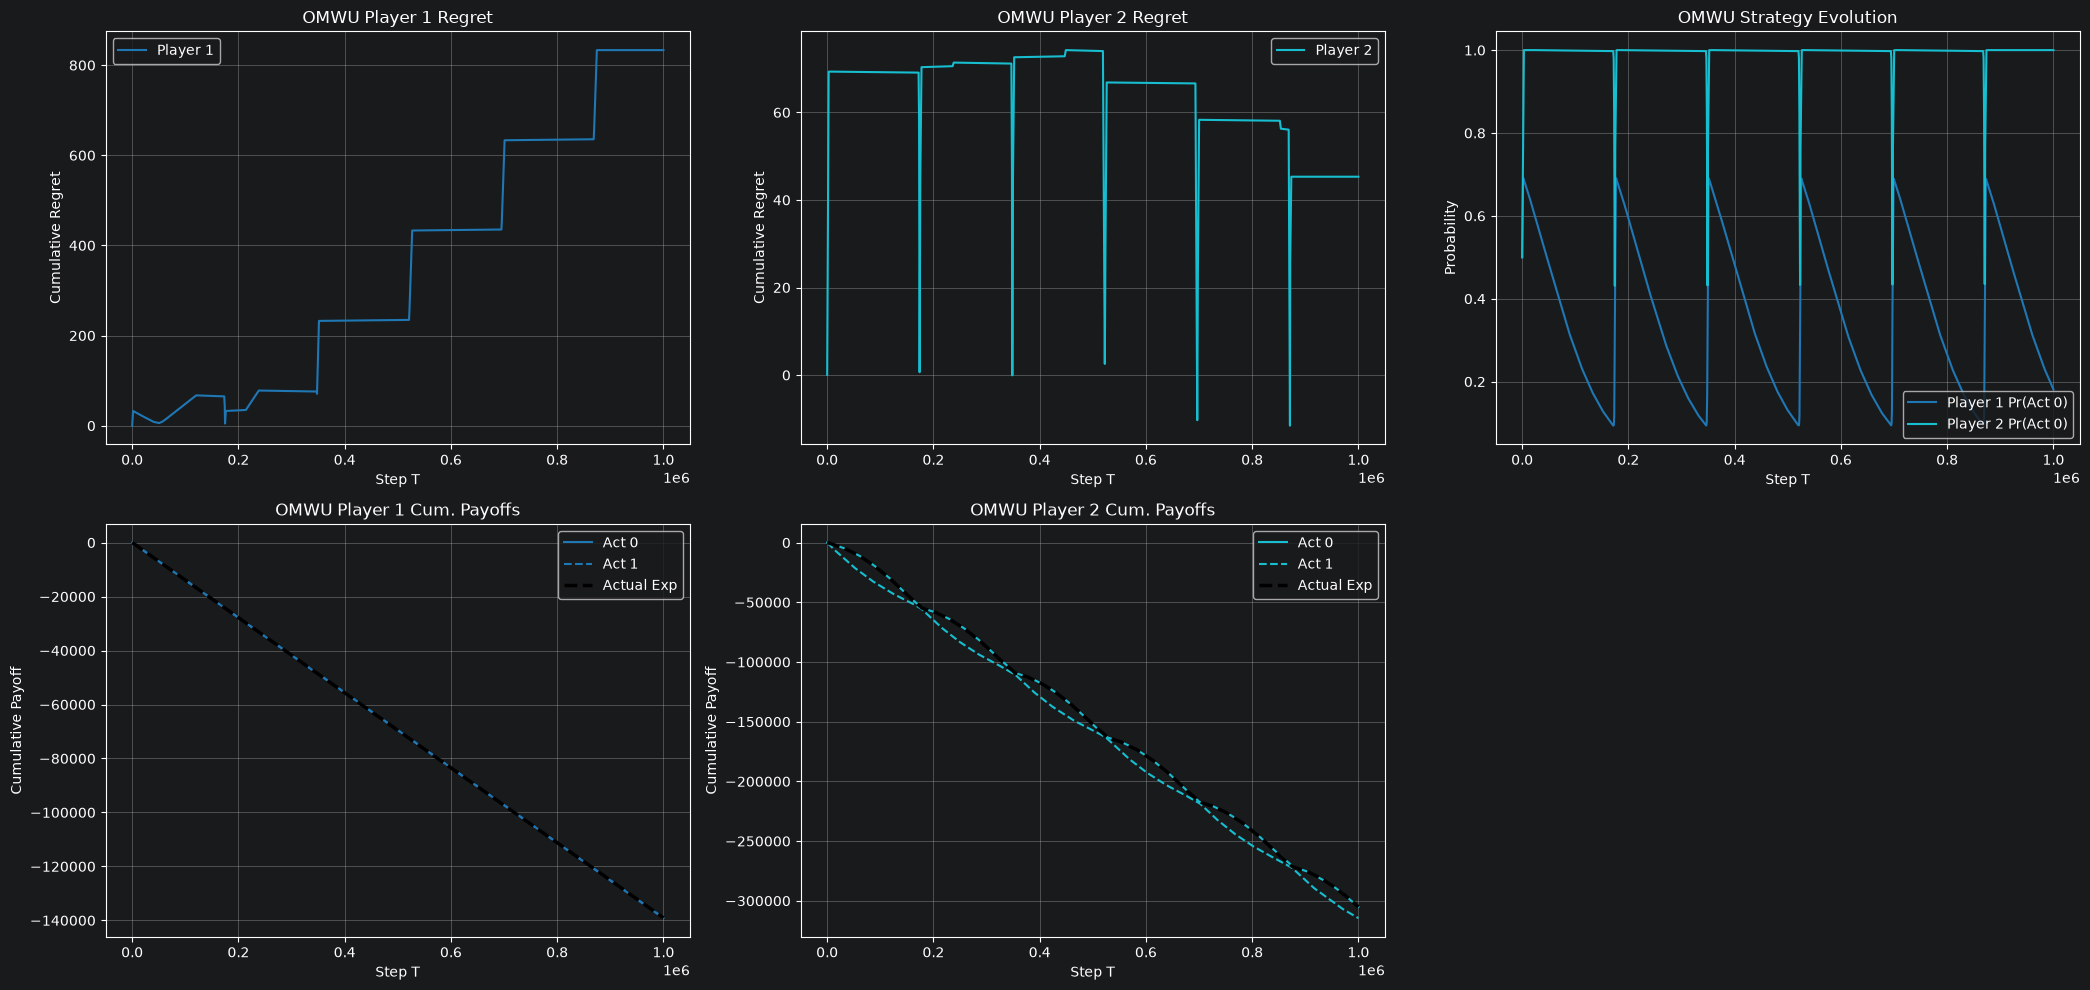

In [5]:
from src.engine.statistics import unpack_stats
from src.utils.visualization import plot_static_trajectories

# Load and unpack the recorded statistics from disk
stats_data = load_experiment_stats(output_dir=output_dir, session_id=session_id)
steps, cum_regrets, strats, logits, instant_payoffs = unpack_stats(stats_data)

# Plot the static N-player trajectories (Zoom in by setting start_step and end_step if desired!)
import torch
cum_action_payoffs = [torch.cumsum(p, dim=0) for p in instant_payoffs]
cum_expected_payoffs = [torch.cumsum(torch.sum(s * p, dim=-1), dim=0) for s, p in zip(strats, instant_payoffs)]
fig, axes = plot_static_trajectories(steps, cum_regrets, strats, title_prefix="OMWU", plot_all_actions=False, start_step=0, end_step=None, separate_regret_plots=True, cum_action_payoffs=cum_action_payoffs, cum_expected_payoffs=cum_expected_payoffs)
plt.show()


In [6]:
from src.utils.visualization import create_learning_dynamics_animation

# Tunable animation parameters
max_frames = 300   # Total frames in the video (subsamples the 800k steps)
fps = 30           # Framerate (300 frames @ 30fps = 10 second video)
tail_length = 50   # How many past frames the strategy phase portrait tail shows
save_path = "cmaes_omwu_animation.mp4" # Save directly to an mp4 file

# Create and save the animation
import torch
cum_action_payoffs = [torch.cumsum(p, dim=0) for p in instant_payoffs]
cum_expected_payoffs = [torch.cumsum(torch.sum(s * p, dim=-1), dim=0) for s, p in zip(strats, instant_payoffs)]
ani = create_learning_dynamics_animation(
    steps, cum_regrets, strats,
    logits=logits,
    instant_payoffs=instant_payoffs,
    cum_action_payoffs=cum_action_payoffs,
    cum_expected_payoffs=cum_expected_payoffs,
    max_frames=max_frames,
    fps=fps,
    tail_length=tail_length,
    save_path=save_path
)




Rendering Animation:   0%|          | 0/300 [00:00<?, ?it/s]

Animation successfully saved to C:\Users\guyv2\PycharmProjects\learning-and-games-final-project\notebooks\cmaes_omwu_animation.mp4


In [7]:
from src.utils.visualization import create_learning_dynamics_animation


# Tunable animation parameters
max_frames = 300   # Total frames in the video (subsamples the 800k steps)
fps = 30           # Framerate (300 frames @ 30fps = 10 second video)
tail_length = 50   # How many past frames the strategy phase portrait tail shows
save_path = "cmaes_omwu_animation_higher_res.mp4" # Save directly to an mp4 file

# Create and save the animation
import torch
cum_action_payoffs = [torch.cumsum(p, dim=0) for p in instant_payoffs]
cum_expected_payoffs = [torch.cumsum(torch.sum(s * p, dim=-1), dim=0) for s, p in zip(strats, instant_payoffs)]
ani = create_learning_dynamics_animation(
    steps, cum_regrets, strats,
    logits=logits,
    instant_payoffs=instant_payoffs,
    cum_action_payoffs=cum_action_payoffs,
    cum_expected_payoffs=cum_expected_payoffs,
    start_step=170000,
    end_step=210000,
    max_frames=max_frames,
    fps=fps,
    tail_length=tail_length,
    save_path=save_path
)




Rendering Animation:   0%|          | 0/300 [00:00<?, ?it/s]

Animation successfully saved to C:\Users\guyv2\PycharmProjects\learning-and-games-final-project\notebooks\cmaes_omwu_animation_higher_res.mp4
